<a href="https://colab.research.google.com/github/kinncode/100/blob/main/SNANet10_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SNANet 訓練 Notebook
**Zhu et al., Applied Acoustics 211 (2023) 109552**

使用流程：
1. 本地電腦跑 `prepare_for_colab.py` 切割 DeepShip
2. 上傳 `processed/` 到 Google Drive
3. 執行本 Notebook（Stage 2-4 全在這裡）

---
**斷點續訓：** Colab timeout 後重新執行即可，自動載入最新 checkpoint。

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import zipfile
import shutil
from pathlib import Path
from google.colab import drive

# 1. 掛載 Google Drive (加入防呆機制，避免重複掛載報錯)
try:
    drive.mount('/content/drive', force_remount=True)
except ValueError:
    pass

# ================================================================
# ⚙️ 路徑設定
# ================================================================
GDRIVE_ROOT = Path('/content/drive/MyDrive/DS1')
ZIP_PATH    = GDRIVE_ROOT / 'processedV.zip'  # 你在 Drive 上打包的壓縮檔
CODE_ROOT   = GDRIVE_ROOT / 'snanet'
CKPT_DIR    = GDRIVE_ROOT / 'checkpoints'
LOG_DIR     = GDRIVE_ROOT / 'logs'

# ================================================================
# 🚀 核心修改：設定 Colab 本地高速硬碟路徑
# ================================================================
LOCAL_DATA_ROOT = Path('/content/dataset/processedV!') # 將路徑從 processedV 修改為 processedV!

# 檢查是否已經解壓縮過（避免 Colab 斷線重連時浪費時間重複解壓）
if not LOCAL_DATA_ROOT.exists():
    print("🚀 開始將資料從 Drive 複製並解壓縮至 Colab 本地高速硬碟 (這會花幾分鐘)...")
    LOCAL_DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)

    # 先把整個 zip 複製到 Colab 本地，這樣解壓縮最快
    local_zip_path = '/content/dataset.zip'
    shutil.copy(ZIP_PATH, local_zip_path)

    print("📦 檔案複製完成，開始解壓縮...")
    with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/dataset/')
    print("✓ 解壓縮完成！")
else:
    print("✓ 本地資料已存在，無需重複解壓縮。")

# 強制將 DATA_ROOT 指向讀取速度最快的本地端
DATA_ROOT = LOCAL_DATA_ROOT

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

import sys
sys.path.insert(0, str(CODE_ROOT))

# 確認資料是否正確掛載
meta_path = DATA_ROOT / 'metadata.csv'
assert meta_path.exists(), f'找不到 metadata.csv，請確認解壓縮是否成功：{DATA_ROOT}'

print(f'✓ 程式碼路徑：{CODE_ROOT}')
print(f'✓ 高速訓練資料路徑：{DATA_ROOT}')

Mounted at /content/drive
✓ 本地資料已存在，無需重複解壓縮。
✓ 程式碼路徑：/content/drive/MyDrive/DS1/snanet
✓ 高速訓練資料路徑：/content/dataset/processedV!


## Step 0：Mount Google Drive

In [ ]:
from pathlib import Path

# ================================================================
# ⚙️  修改這裡：你的 Google Drive 路徑
# ================================================================
GDRIVE_ROOT = Path('/content/drive/MyDrive/DS/')
DATA_ROOT   = GDRIVE_ROOT / '/content/drive/MyDrive/DS/processed'   # 切割後的資料
CODE_ROOT   = GDRIVE_ROOT / 'snanet'               # 程式碼
CKPT_DIR    = GDRIVE_ROOT / 'checkpoints'
LOG_DIR     = GDRIVE_ROOT / 'logs'
# ================================================================

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

# 確認資料在
meta_path = DATA_ROOT / 'metadata.csv'
assert meta_path.exists(), f'找不到 metadata.csv，請確認 DATA_ROOT 路徑正確：{DATA_ROOT}'
print(f'✓ 資料找到：{DATA_ROOT}')

import sys
sys.path.insert(0, str(CODE_ROOT))
print(f'✓ 程式碼路徑：{CODE_ROOT}')

✓ 資料找到：/content/drive/MyDrive/DS/processed
✓ 程式碼路徑：/content/drive/MyDrive/DS/snanet


## Step 1：安裝依賴

In [4]:
%%capture
!pip install nnAudio librosa soundfile pandas tqdm
print('✓ 依賴安裝完成')

## Step 2：確認環境 + 資料分佈

In [5]:
import torch
import pandas as pd

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# 確認資料分佈
meta = pd.read_csv(DATA_ROOT / 'metadata.csv')
print('\n=== 資料分佈 ===')
print(meta.groupby(['class', 'split']).size().unstack(fill_value=0))
print(f'\nTrain: {(meta.split=="train").sum()}')
print(f'Test:  {(meta.split=="test").sum()}')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB

=== 資料分佈 ===
split          test  train
class                     
Cargo          3584   9217
Passengership  4815  10595
Tanker         3877  10885
Tug            4672   8823

Train: 39520
Test:  16948


## Step 3：設定超參數

In [6]:
from dataclasses import dataclass
from typing import List

@dataclass(frozen=True)
class FeatureSpec:
    name: str
    feat_type: str
    fmin: float
    fmax: float
    n_filters: int
    win_size: int
    pre_emphasis: float
    role: str

# Paper Table 2 - Adjusted CQT fmin to avoid oversized kernels
FEATURE_SPECS: List[FeatureSpec] = [
    FeatureSpec('mel_1_100',  'mel', 1.0,    100.0,  20, 400,  0.00, 'auxiliary'),
    FeatureSpec('mel_100_1k', 'mel', 100.0,  1000.0, 40, 400,  0.00, 'auxiliary'),
    FeatureSpec('mel_1k_16k', 'mel', 1000.0, 16000., 84, 4096, 0.97, 'auxiliary'),
    FeatureSpec('cqt_1_16k',  'cqt', 20.0,   16000., 84, 4096, 0.97, 'main'), # Changed fmin 1.0 -> 20.0
    FeatureSpec('mel_1_16k',  'mel', 1.0,   16000., 84, 400,  0.97, 'main'),
]

CLASSES      = ['Background', 'Cargo', 'Passengership', 'Tanker', 'Tug']
NUM_CLASSES  = len(CLASSES)
SAMPLE_RATE  = 32_000
SEGMENT_LEN  = 96_000

EPOCHS      = 10
BATCH_SIZE  = 64
LR          = 5e-5
WEIGHT_DECAY = 2e-5
LR_DECAY    = 0.97
SEED        = 42

import torch, numpy as np
torch.manual_seed(SEED)
np.random.seed(SEED)
print('✓ 超參數已更新 (EPOCHS=5)')

✓ 超參數已更新 (EPOCHS=5)


## Step 4：Feature Extractor（Stage 2，on-the-fly）

In [7]:
import torch
import torch.nn.functional as F
import numpy as np

try:
    import nnAudio.features as nnAF
    HAS_NNAUDIO = True
    print('✓ nnAudio 卡用——GPU 分递——')
except ImportError:
    HAS_NNAUDIO = False
    import librosa
    print('☠ 䈱用 librosa fallback')

class SingleFeatureExtractor:
    def __init__(self, spec: FeatureSpec, device='cpu'):
        self.spec = spec
        self.device = device
        if HAS_NNAUDIO:
            if spec.feat_type == 'mel':
                self.extractor = nnAF.MelSpectrogram(
                    sr=SAMPLE_RATE, n_mels=spec.n_filters,
                    n_fft=spec.win_size, fmin=spec.fmin, fmax=spec.fmax
                ).to(device)
            else:
                # pad_mode='constant' to avoid reflection padding issues with short signals
                self.extractor = nnAF.CQT(
                    sr=SAMPLE_RATE, hop_length=160,
                    fmin=spec.fmin, n_bins=spec.n_filters, pad_mode='constant'
                ).to(device)

    def _preemphasis(self, x: np.ndarray) -> np.ndarray:
        if self.spec.pre_emphasis == 0:
            return x
        return np.append(x[0:1], x[1:] - self.spec.pre_emphasis * x[:-1])

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        B = x.shape[0]
        if HAS_NNAUDIO:
            wav = x.squeeze(1).to(self.device)
            with torch.no_grad():
                try:
                    feat = self.extractor(wav)
                except RuntimeError:
                    # Fallback to librosa if nnAudio still fails due to padding
                    return self._librosa_fallback(x)
            feat_db = 10 * torch.log10(feat + 1e-9)
            feat_np = feat_db.cpu().numpy()
        else:
            feat_np = self._librosa_fallback_np(x)

        mn = feat_np.min(axis=(1,2), keepdims=True)
        mx = feat_np.max(axis=(1,2), keepdims=True)
        feat_np = (feat_np - mn) / (mx - mn + 1e-6)
        t = torch.from_numpy(feat_np).float().unsqueeze(1)
        t = F.interpolate(t, size=(64, 64), mode='bilinear', align_corners=False)
        return t

    def _librosa_fallback_np(self, x: torch.Tensor):
        x_np = x.squeeze(1).numpy()
        feats = []
        for i in range(x.shape[0]):
            wav = self._preemphasis(x_np[i])
            if self.spec.feat_type == 'mel':
                S = librosa.feature.melspectrogram(y=wav, sr=SAMPLE_RATE, n_mels=self.spec.n_filters, n_fft=self.spec.win_size, fmin=self.spec.fmin, fmax=self.spec.fmax)
            else:
                S = np.abs(librosa.cqt(y=wav, sr=SAMPLE_RATE, fmin=self.spec.fmin, n_bins=self.spec.n_filters))**2
            feats.append(librosa.power_to_db(S, ref=np.max))
        return np.stack(feats)

    def _librosa_fallback(self, x: torch.Tensor):
        feat_np = self._librosa_fallback_np(x)
        mn = feat_np.min(axis=(1,2), keepdims=True)
        mx = feat_np.max(axis=(1,2), keepdims=True)
        feat_np = (feat_np - mn) / (mx - mn + 1e-6)
        t = torch.from_numpy(feat_np).float().unsqueeze(1)
        return F.interpolate(t.to(self.device), size=(64, 64), mode='bilinear', align_corners=False)

class MultiFeatureExtractor:
    def __init__(self, specs: List[FeatureSpec], device='cpu'):
        self.extractors = {s.name: SingleFeatureExtractor(s, device) for s in specs}
    def __call__(self, x: torch.Tensor) -> dict:
        return {name: ext(x) for name, ext in self.extractors.items()}

feat_ext = MultiFeatureExtractor(FEATURE_SPECS, device=device)
dummy = torch.randn(2, 1, SEGMENT_LEN)
feats = feat_ext(dummy)
for name, f in feats.items():
    print(f'  {name}: {tuple(f.shape)}')
print('✓ FeatureExtractor OK')

✓ nnAudio 卡用——GPU 分递——
STFT kernels created, time used = 0.0780 seconds
STFT filter created, time used = 0.0013 seconds
Mel filter created, time used = 0.0013 seconds


/usr/local/lib/python3.12/dist-packages/nnAudio/librosa_functions.py:479: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  warnings.warn(


STFT kernels created, time used = 0.0095 seconds
STFT filter created, time used = 0.0008 seconds
Mel filter created, time used = 0.0009 seconds
STFT kernels created, time used = 0.9129 seconds
STFT filter created, time used = 0.0054 seconds
Mel filter created, time used = 0.0055 seconds
CQT kernels created, time used = 0.1864 seconds
STFT kernels created, time used = 0.0053 seconds
STFT filter created, time used = 0.0009 seconds
Mel filter created, time used = 0.0009 seconds
  mel_1_100: (2, 1, 64, 64)
  mel_100_1k: (2, 1, 64, 64)
  mel_1k_16k: (2, 1, 64, 64)
  cqt_1_16k: (2, 1, 64, 64)
  mel_1_16k: (2, 1, 64, 64)
✓ FeatureExtractor OK


## Step 5：Dataset + DataLoader

In [8]:
import soundfile as sf
from torch.utils.data import Dataset, DataLoader

CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

class DeepShipDataset(Dataset):
    def __init__(self, root, split, feature_extractor=None, fraction=1.0):
        self.root = Path(root)
        meta = pd.read_csv(self.root / 'metadata.csv')
        self.meta = meta[meta.split == split].reset_index(drop=True)

        # 如果 fraction < 1.0，則隨機取樣減少資料量
        if fraction < 1.0:
            self.meta = self.meta.sample(frac=fraction, random_state=SEED).reset_index(drop=True)

        self.feat_ext = feature_extractor

    def __len__(self):
        return len(self.meta)

    def _load(self, rel_path):
        p = self.root / str(rel_path).replace('\\', '/')
        x = np.load(p) if p.suffix == '.npy' else sf.read(p, dtype='float32')[0]
        if x.ndim > 1: x = x.mean(1)
        if len(x) < SEGMENT_LEN:
            x = np.pad(x, (0, SEGMENT_LEN - len(x)))
        return x[:SEGMENT_LEN].astype(np.float32)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        x = torch.from_numpy(self._load(row.path)).unsqueeze(0)
        y = int(row.label)
        if self.feat_ext:
            x_dict = self.feat_ext(x.unsqueeze(0))
            x = {k: v.squeeze(0) for k, v in x_dict.items()}
        return x, y

# 修改 fraction=0.1 代表只取 10% 的資料進行訓練測試
ds_train = DeepShipDataset(DATA_ROOT, 'train', feat_ext, fraction=0.1)
ds_test  = DeepShipDataset(DATA_ROOT, 'test',  feat_ext, fraction=0.1)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(ds_train):,} samples (Subset)')
print(f'Test:  {len(ds_test):,} samples (Subset)')

Train: 3,952 samples (Subset)
Test:  1,695 samples (Subset)


## Step 6：SNANet 模型（Stage 3）

In [9]:
import torch.nn as nn
import torchvision.models as tvm


class ECA(nn.Module):
    """Efficient Channel Attention (Wang et al., CVPR 2020)"""
    def __init__(self, channels, k=3):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, k, padding=k//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        y = self.avg(x).squeeze(-1).transpose(-1, -2)  # [B, 1, C]
        y = self.conv(y).transpose(-1, -2).unsqueeze(-1)  # [B, C, 1, 1]
        return x * self.sigmoid(y)


class ResNet18ECA(nn.Module):
    """ResNet18 backbone with ECA attention（Paper Section 3.2）"""
    def __init__(self, in_channels=1, num_classes=5):
        super().__init__()
        base = tvm.resnet18(weights=None)
        # 改 in_channels（原本是 3，改為 1）
        base.conv1 = nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False)
        self.layer0 = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        self.eca1 = ECA(64)
        self.eca2 = ECA(128)
        self.eca3 = ECA(256)
        self.eca4 = ECA(512)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.layer0(x)
        x = self.eca1(self.layer1(x))
        x = self.eca2(self.layer2(x))
        x = self.eca3(self.layer3(x))
        x = self.eca4(self.layer4(x))
        x = self.pool(x).flatten(1)
        return self.fc(x)


class SNANet(nn.Module):
    """
    完整 SNANet
    - 4 個分支（f1-f4）各自用 ResNet18+ECA
    - 自適應權重融合（Eq. 4-8）
    """
    def __init__(self, num_classes=5):
        super().__init__()
        # 4 個頻帶各自一個 backbone
        self.backbone_f1 = ResNet18ECA(1, num_classes)  # 1-100Hz
        self.backbone_f2 = ResNet18ECA(1, num_classes)  # 100Hz-1kHz
        self.backbone_f3 = ResNet18ECA(1, num_classes)  # 1k-16kHz
        self.backbone_f4 = ResNet18ECA(1, num_classes)  # 1-16kHz (main)

        # Backward weight：1D conv on concatenated feature
        self.bw_conv = nn.Conv1d(1, 1, 3, padding=1, bias=False)
        self.bw_sig  = nn.Sigmoid()

        # Final classifier（mixed feature）
        self.final_cls = nn.Linear(512 * 4, num_classes)

    def get_features(self, x, backbone):
        """取 backbone 的 feature（fc 之前）"""
        x = backbone.layer0(x)
        x = backbone.eca1(backbone.layer1(x))
        x = backbone.eca2(backbone.layer2(x))
        x = backbone.eca3(backbone.layer3(x))
        x = backbone.eca4(backbone.layer4(x))
        return backbone.pool(x).flatten(1)  # [B, 512]

    def forward(self, x_dict: dict, forward_weights=None):
        """
        x_dict: {spec.name: [B, 1, 64, 64]}
        forward_weights: [4] (訓練時由 acc 計算，測試時設為 1.0)
        """
        # 取各頻帶的 feature
        f1 = self.get_features(x_dict['mel_1_100'],  self.backbone_f1)   # [B, 512]
        f2 = self.get_features(x_dict['mel_100_1k'], self.backbone_f2)
        f3 = self.get_features(x_dict['mel_1k_16k'], self.backbone_f3)
        f4 = self.get_features(x_dict['mel_1_16k'],  self.backbone_f4)

        # Classifier 輸出（Eq. 6 需要 accuracy）
        logits_f1 = self.backbone_f1.fc(f1)
        logits_f2 = self.backbone_f2.fc(f2)
        logits_f3 = self.backbone_f3.fc(f3)
        logits_f4 = self.backbone_f4.fc(f4)

        # Backward weight Bf（Eq. 5）
        combined = torch.stack([f1, f2, f3, f4], dim=1)  # [B, 4, 512]
        gap = combined.mean(dim=2, keepdim=True)          # [B, 4, 1]
        gap_t = gap.transpose(1, 2)                       # [B, 1, 4]
        bw = self.bw_sig(self.bw_conv(gap_t))             # [B, 1, 4]
        bw = bw.squeeze(1)                                # [B, 4]

        # Forward weight Ff（Eq. 6）—訓練時由上一 epoch accuracy 提供
        if forward_weights is None:
            fw = torch.ones(4, device=f1.device)
        else:
            fw = torch.tensor(forward_weights, device=f1.device)
        fw = fw / fw.sum()  # normalize

        # Adaptive weight Wf = Ff * Bf（Eq. 4）
        fs = torch.stack([f1, f2, f3, f4], dim=1)   # [B, 4, 512]
        wf = (fw.unsqueeze(0) * bw).unsqueeze(2)     # [B, 4, 1]
        mixed = (fs * wf).view(fs.shape[0], -1)      # [B, 4*512]

        logits_mixed = self.final_cls(mixed)

        return {
            'f1': logits_f1, 'f2': logits_f2,
            'f3': logits_f3, 'f4': logits_f4,
            'mixed': logits_mixed,
        }


model = SNANet(NUM_CLASSES).to(device)
total = sum(p.numel() for p in model.parameters())
print(f'✓ SNANet 建立完成，參數量：{total:,}')

✓ SNANet 建立完成，參數量：44,701,516


## Step 7：Loss 函式（Mixed Loss，Eq. 7-8）

In [10]:
import torch

def mixed_loss(outputs: dict, targets: torch.Tensor, accs: list) -> torch.Tensor:
    """
    Mixed Loss（Paper Eq. 7-8）
    L_total = Σ w_fi * l_fi
    w_fi = exp(1 - A_fi) / Σ exp(1 - A_fi)

    5 個 classifier（f1-f4 + mixed）
    accs: list of 5 floats（上一 epoch 各 classifier 的 accuracy）
    """
    ce = torch.nn.functional.cross_entropy

    keys = ['f1', 'f2', 'f3', 'f4', 'mixed']
    losses = torch.stack([
        ce(outputs[k], targets) for k in keys
    ])

    # Eq. 8
    a = torch.tensor(accs, device=targets.device, dtype=torch.float)
    w = torch.exp(1 - a)
    w = w / w.sum()

    return (w * losses).sum()


print('✓ Mixed Loss 定義完成')

✓ Mixed Loss 定義完成


## Step 8：訓練迴圈（支援斷點續訓）

In [11]:
import torch.optim as optim
from tqdm.notebook import tqdm
import json

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=LR_DECAY)


def save_checkpoint(epoch, model, optimizer, scheduler, accs, history):
    path = CKPT_DIR / f'ckpt_epoch_{epoch:03d}.pt'
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'accs': accs,
        'history': history,
    }, path)
    # 只保留最新的 3 個 checkpoint（省 Drive 空間）
    ckpts = sorted(CKPT_DIR.glob('ckpt_epoch_*.pt'))
    for old in ckpts[:-3]:
        old.unlink()


def load_latest_checkpoint():
    ckpts = sorted(CKPT_DIR.glob('ckpt_epoch_*.pt'))
    if not ckpts:
        return None
    return torch.load(ckpts[-1], map_location=device)


def evaluate(model, dl, device):
    model.eval()
    keys = ['f1', 'f2', 'f3', 'f4', 'mixed']
    correct = {k: 0 for k in keys}
    total = 0
    with torch.no_grad():
        for x_dict, y in dl:
            x_dict = {k: v.to(device) for k, v in x_dict.items()}
            y = y.to(device)
            out = model(x_dict)
            for k in keys:
                correct[k] += (out[k].argmax(1) == y).sum().item()
            total += y.size(0)
    return {k: correct[k] / total for k in keys}


# 載入 checkpoint（如果有）
start_epoch = 0
history = []
# 初始 accuracy（全為 0.2，即亂猜的 5 分類）
prev_accs = [0.2, 0.2, 0.2, 0.2, 0.2]

ckpt = load_latest_checkpoint()
if ckpt:
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    scheduler.load_state_dict(ckpt['scheduler'])
    start_epoch = ckpt['epoch'] + 1
    prev_accs = ckpt['accs']
    history = ckpt['history']
    print(f'✓ 載入 checkpoint，從 Epoch {start_epoch} 繼續')
else:
    print('✓ 沒有 checkpoint，從頭開始')

print(f'準備開始訓練：Epoch {start_epoch} → {EPOCHS}')

✓ 沒有 checkpoint，從頭開始
準備開始訓練：Epoch 0 → 10


In [12]:
# 正式訓練
for epoch in range(start_epoch, EPOCHS):
    model.train()
    total_loss = 0

    for x_dict, y in tqdm(dl_train, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        x_dict = {k: v.to(device) for k, v in x_dict.items()}
        y = y.to(device)

        optimizer.zero_grad()
        out = model(x_dict, forward_weights=prev_accs[:4])
        loss = mixed_loss(out, y, prev_accs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    # Evaluate
    accs = evaluate(model, dl_test, device)
    prev_accs = [accs['f1'], accs['f2'], accs['f3'], accs['f4'], accs['mixed']]

    row = {'epoch': epoch, 'loss': total_loss / len(dl_train), **accs}
    history.append(row)

    print(f"  loss={row['loss']:.4f} | f1={accs['f1']:.3f} f2={accs['f2']:.3f} "
          f"f3={accs['f3']:.3f} f4={accs['f4']:.3f} | mixed={accs['mixed']:.3f}")

    # 存 checkpoint
    save_checkpoint(epoch, model, optimizer, scheduler, prev_accs, history)

    # 存 log
    pd.DataFrame(history).to_csv(LOG_DIR / 'history.csv', index=False)

print('\n✓ 訓練完成！')
print(f'最終 mixed accuracy：{prev_accs[4]:.4f}')

Epoch 1/10:   0%|          | 0/62 [00:00<?, ?it/s]

  loss=1.3575 | f1=0.267 f2=0.467 f3=0.400 f4=0.525 | mixed=0.392


Epoch 2/10:   0%|          | 0/62 [00:00<?, ?it/s]

  loss=1.1310 | f1=0.437 f2=0.457 f3=0.424 f4=0.528 | mixed=0.504


Epoch 3/10:   0%|          | 0/62 [00:00<?, ?it/s]

...

  loss=0.3725 | f1=0.318 f2=0.453 f3=0.458 f4=0.525 | mixed=0.602


Epoch 9/10:   0%|          | 0/62 [00:00<?, ?it/s]

  loss=0.3395 | f1=0.316 f2=0.450 f3=0.442 f4=0.532 | mixed=0.582


Epoch 10/10:   0%|          | 0/62 [00:00<?, ?it/s]

  loss=0.3271 | f1=0.247 f2=0.455 f3=0.463 f4=0.528 | mixed=0.580

✓ 訓練完成！
最終 mixed accuracy：0.5799


## Step 9：查看結果

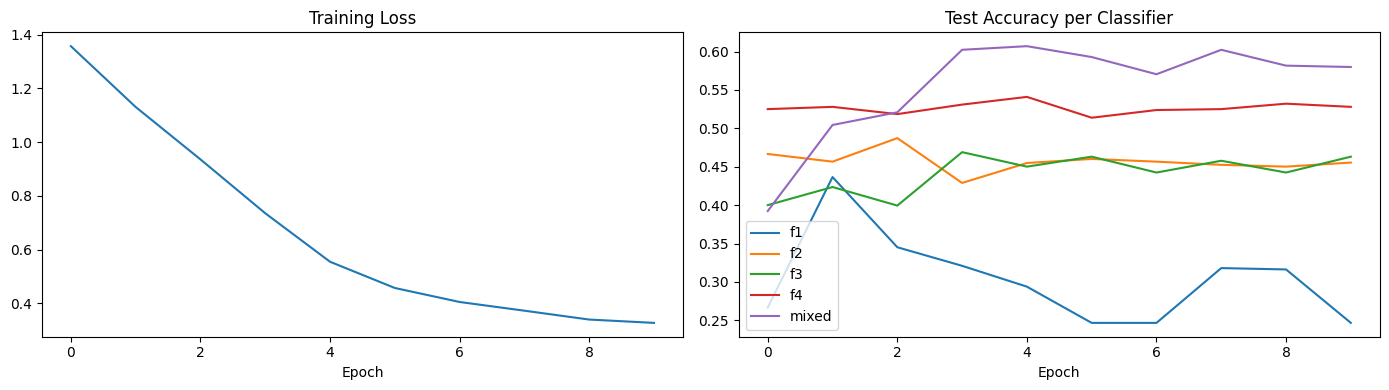

   epoch      loss        f1        f2        f3        f4     mixed
5      5  0.457043  0.246608  0.460177  0.463127  0.513864  0.592920
6      6  0.404931  0.246608  0.456637  0.442478  0.523894  0.570501
7      7  0.372477  0.317994  0.452507  0.457817  0.525074  0.602360
8      8  0.339512  0.316224  0.450147  0.442478  0.532153  0.581711
9      9  0.327086  0.246608  0.455457  0.463127  0.528024  0.579941


In [13]:
import matplotlib.pyplot as plt
import pandas as pd

hist = pd.read_csv(LOG_DIR / 'history.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist.epoch, hist.loss)
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')

for col in ['f1','f2','f3','f4','mixed']:
    axes[1].plot(hist.epoch, hist[col], label=col)
axes[1].set_title('Test Accuracy per Classifier')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(LOG_DIR / 'training_curve.png', dpi=100)
plt.show()

print(hist.tail(5).to_string())

```markdown
## Step 10：繪製混淆矩陣 (Confusion Matrix) 熱圖
```

Evaluating for Heatmap:   0%|          | 0/27 [00:00<?, ?it/s]

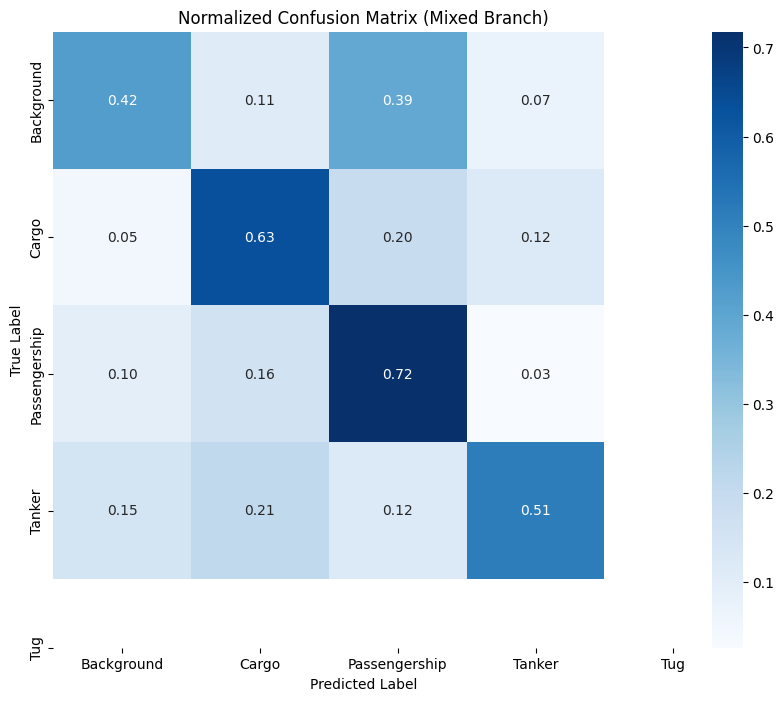

In [16]:

import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, dl, device, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_dict, y in tqdm(dl, desc='Evaluating for Heatmap'):
            x_dict = {k: v.to(device) for k, v in x_dict.items()}
            out = model(x_dict)
            preds = out['mixed'].argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Normalized Confusion Matrix (Mixed Branch)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# 執行繪圖
plot_confusion_matrix(model, dl_test, device, CLASSES)


```markdown
## Step 11：分別針對 CQT 與 Mel 分支繪製熱圖
```

```markdown
### (a) 基於 CQT 特徵的實驗分析
我們將評估 `cqt_1_16k` 分支在測試集上的表現。
```

Evaluating CQT Branch:   0%|          | 0/27 [00:00<?, ?it/s]

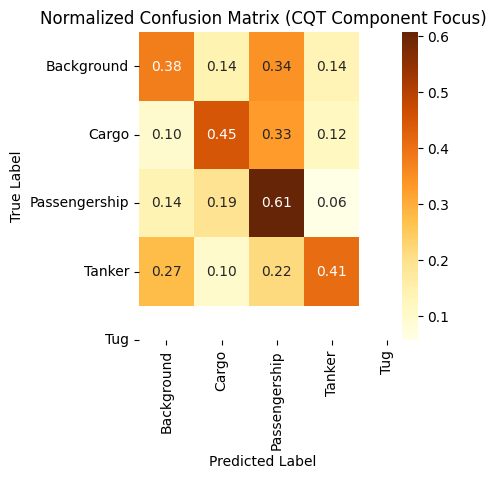

In [21]:
def evaluate_cqt_branch(model, dl, device, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_dict, y in tqdm(dl, desc='Evaluating CQT Branch'):
            x_dict = {k: v.to(device) for k, v in x_dict.items()}

            # 在 SNANet 中，f1, f2, f3 是輔助 Mel 分支
            # f4 是主要的 1-16kHz Mel 分支

            out = model(x_dict)
            # 這裡觀察 f3 分支
            preds = out['f3'].argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrBr',
                xticklabels=classes, yticklabels=classes)
    plt.title('Normalized Confusion Matrix (CQT Component Focus)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# 執行 CQT 分支評估
evaluate_cqt_branch(model, dl_test, device, CLASSES)

### (b) 基於 Mel 特徵的實驗分析
我們將評估主要頻段的 `mel_1_16k` (f4) 分支在測試集上的表現。

Evaluating Mel Branch:   0%|          | 0/27 [00:00<?, ?it/s]

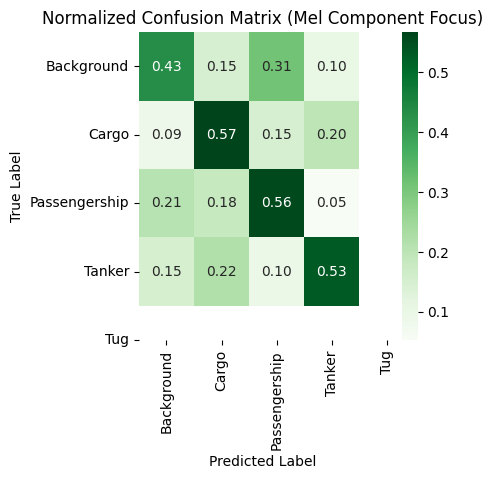

In [22]:
def evaluate_mel_branch(model, dl, device, classes):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_dict, y in tqdm(dl, desc='Evaluating Mel Branch'):
            x_dict = {k: v.to(device) for k, v in x_dict.items()}
            out = model(x_dict)

            # f4 在 SNANet 中對應的是 1-16kHz 的主要 Mel 分支
            preds = out['f4'].argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(4, 4))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=classes, yticklabels=classes)
    plt.title('Normalized Confusion Matrix (Mel Component Focus)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# 執行 Mel 分支評估
evaluate_mel_branch(model, dl_test, device, CLASSES)

### Step 12：CQT (f3) 與 Mel (f4) 分支對比分析
我們將兩者的混淆矩陣並排顯示，以便觀察不同特徵對於特定類別的誤判傾向。

Comparing Branches:   0%|          | 0/27 [00:00<?, ?it/s]

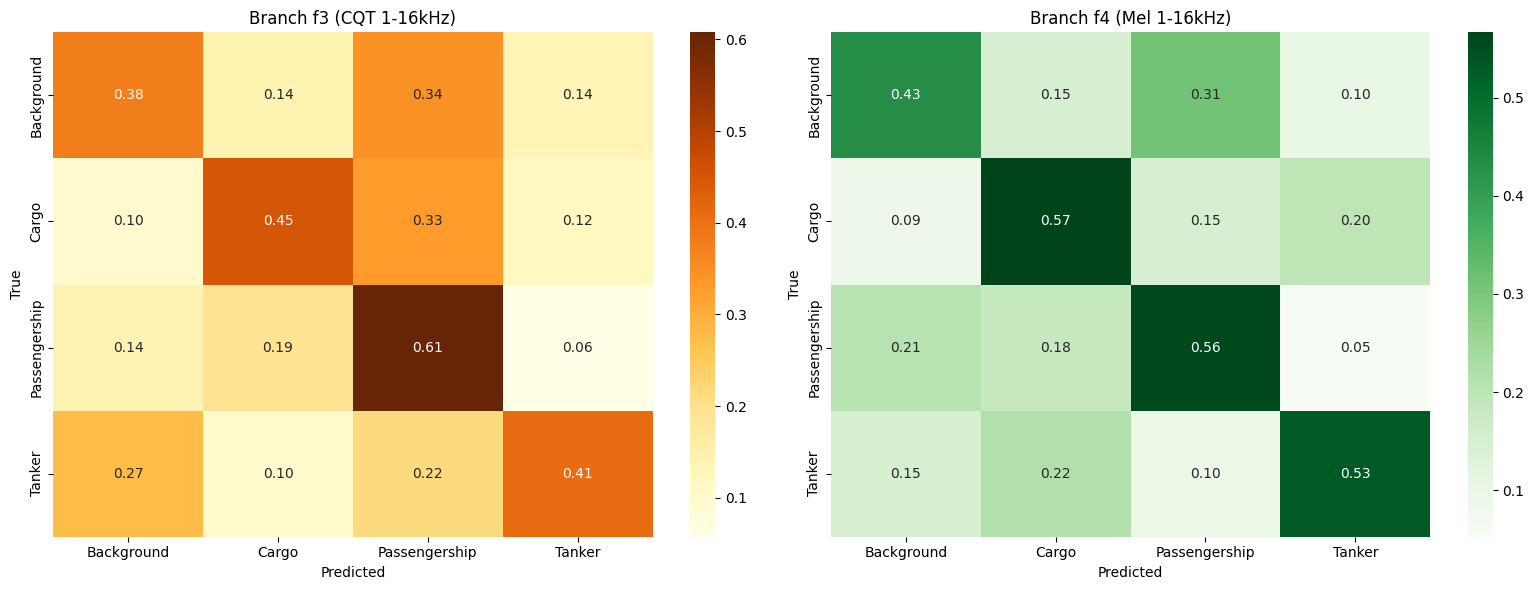


=== 類別準確度對比 (Recall) ===
Background      | f3: 0.379 | f4: 0.434 | Diff: +0.055
Cargo           | f3: 0.450 | f4: 0.567 | Diff: +0.117
Passengership   | f3: 0.608 | f4: 0.557 | Diff: -0.050
Tanker          | f3: 0.408 | f4: 0.532 | Diff: +0.124


In [41]:
def compare_branches(model, dl, device, classes):
    model.eval()
    preds_f3, preds_f4, labels = [], [], []

    with torch.no_grad():
        for x_dict, y in tqdm(dl, desc='Comparing Branches'):
            x_dict = {k: v.to(device) for k, v in x_dict.items()}
            out = model(x_dict)

            preds_f3.extend(out['f3'].argmax(1).cpu().numpy())
            preds_f4.extend(out['f4'].argmax(1).cpu().numpy())
            labels.extend(y.numpy())

    # 找出實際出現在 labels 中的類別編號，避免索引越界
    present_indices = np.unique(labels)
    present_classes = [classes[i] for i in present_indices]

    cm_f3 = confusion_matrix(labels, preds_f3)
    cm_f4 = confusion_matrix(labels, preds_f4)

    # 修正：如果樣本數為 0 避免除以 0
    cm_f3_norm = cm_f3.astype('float') / (cm_f3.sum(axis=1)[:, np.newaxis] + 1e-9)
    cm_f4_norm = cm_f4.astype('float') / (cm_f4.sum(axis=1)[:, np.newaxis] + 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm_f3_norm, annot=True, fmt='.2f', cmap='YlOrBr', ax=axes[0],
                xticklabels=present_classes, yticklabels=present_classes)
    axes[0].set_title('Branch f3 (CQT 1-16kHz)')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')

    sns.heatmap(cm_f4_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
                xticklabels=present_classes, yticklabels=present_classes)
    axes[1].set_title('Branch f4 (Mel 1-16kHz)')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')

    plt.tight_layout()
    plt.show()

    # 列印各類別準確度差異
    print("\n=== 類別準確度對比 (Recall) ===")
    # 關鍵修正：遍歷 present_classes 而不是原始 classes
    for i, cls_name in enumerate(present_classes):
        diff = cm_f4_norm[i,i] - cm_f3_norm[i,i]
        print(f"{cls_name:15s} | f3: {cm_f3_norm[i,i]:.3f} | f4: {cm_f4_norm[i,i]:.3f} | Diff: {diff:+.3f}")

compare_branches(model, dl_test, device, CLASSES)

### (c) CQT 分支 (f3) 實驗數據彙整
針對 CQT 特徵分支在測試集上的歷史準確度進行統計分析。

=== CQT (f3) 實驗表現分析 ===
實驗次數 (Experiment Times/Epochs): 10
最高準確度 (Max Accuracy): 46.90% (Epoch 3)
平均準確度 (Mean Accuracy): 44.11%
最終準確度 (Final Accuracy): 46.31%


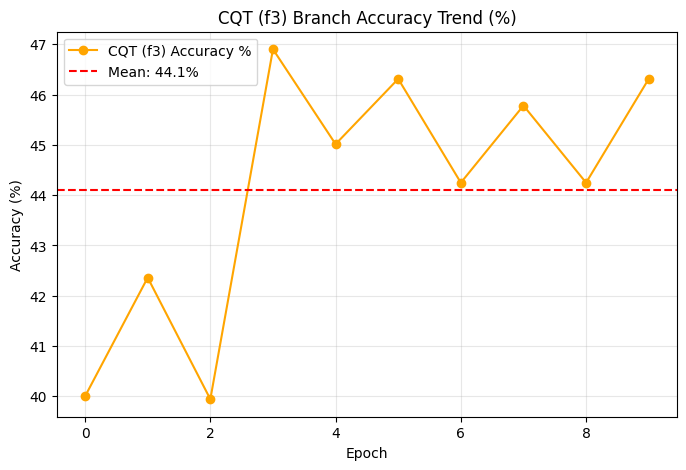

In [26]:
# 提取歷史紀錄中的 f3 準確度
f3_accs = hist['f3'].values

print(f"=== CQT (f3) 實驗表現分析 ===")
print(f"實驗次數 (Experiment Times/Epochs): {len(f3_accs)}")
print(f"最高準確度 (Max Accuracy): {f3_accs.max()*100:.2f}% (Epoch {f3_accs.argmax()})")
print(f"平均準確度 (Mean Accuracy): {f3_accs.mean()*100:.2f}%")
print(f"最終準確度 (Final Accuracy): {f3_accs[-1]*100:.2f}%")

# 繪製 f3 的準確度趨勢圖
plt.figure(figsize=(8, 5))
plt.plot(hist['epoch'], hist['f3']*100, marker='o', color='orange', label='CQT (f3) Accuracy %')
plt.axhline(y=f3_accs.mean()*100, color='red', linestyle='--', label=f'Mean: {f3_accs.mean()*100:.1f}%')
plt.title('CQT (f3) Branch Accuracy Trend (%)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### (d) CQT 分支 (f3) 詳細指標分析 (消融實驗 B)
我們將計算 f3 分支在測試集上的 Macro Precision, Recall 與 F1-score。

In [31]:
from sklearn.metrics import precision_recall_fscore_support

def get_cqt_metrics(model, dl, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x_dict, y in tqdm(dl, desc='Calculating CQT Metrics'):
            x_dict = {k: v.to(device) for k, v in x_dict.items()}
            out = model(x_dict)
            all_preds.extend(out['f3'].argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())

    p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    acc = (np.array(all_preds) == np.array(all_labels)).mean()

    df = pd.DataFrame([{
        'Method': 'Ablation B (CQT-f3)',
        'Accuracy (%)': f"{acc*100:.2f}%",
        'Precision (%)': f"{p*100:.2f}%",
        'Recall (%)': f"{r*100:.2f}%",
        'F1-score (%)': f"{f1*100:.2f}%"
    }])
    return df

cqt_ablation_results = get_cqt_metrics(model, dl_test, device)
display(cqt_ablation_results)

Calculating CQT Metrics:   0%|          | 0/27 [00:00<?, ?it/s]

,Method,Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,Ablation B (CQT-f3),46.31%,47.63%,46.11%,45.82%


### (e) 消融實驗 A 數據彙整：Mel 特徵分支
針對 SNANet 中各個 Mel 頻帶分支進行指標分析，包括輔助分支 (f1, f2) 與主分支 (f4)。

In [30]:
from sklearn.metrics import precision_recall_fscore_support

def get_all_branch_metrics(model, dl, device):
    model.eval()
    results = []
    # 定義所有要對比的分支
    branches = {
        'f1 (Mel 1-100Hz)': 'f1',
        'f2 (Mel 100-1kHz)': 'f2',
        'f3 (CQT 1-16kHz)': 'f3',
        'f4 (Mel 1-16kHz)': 'f4',
        'Mixed Feature': 'mixed'
    }

    all_preds = {k: [] for k in branches.keys()}
    all_labels = []

    with torch.no_grad():
        for x_dict, y in tqdm(dl, desc='Calculating All Metrics'):
            x_dict = {k: v.to(device) for k, v in x_dict.items()}
            out = model(x_dict)
            for label, key in branches.items():
                all_preds[label].extend(out[key].argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())

    for label in branches.keys():
        preds = np.array(all_preds[label])
        labels = np.array(all_labels)

        acc = (preds == labels).mean()
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)

        results.append({
            'Feature / Branch': label,
            'Accuracy (%)': f"{acc*100:.2f}%",
            'Precision (%)': f"{p*100:.2f}%",
            'Recall (%)': f"{r*100:.2f}%",
            'F1-score (%)': f"{f1*100:.2f}%"
        })

    return pd.DataFrame(results)

# 執行並顯示完整對照表
full_ablation_results = get_all_branch_metrics(model, dl_test, device)
display(full_ablation_results)

Calculating All Metrics:   0%|          | 0/27 [00:00<?, ?it/s]

,Feature / Branch,Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,f1 (Mel 1-100Hz),24.66%,29.35%,25.03%,10.37%
1,f2 (Mel 100-1kHz),45.55%,45.73%,45.14%,45.17%
2,f3 (CQT 1-16kHz),46.31%,47.63%,46.11%,45.82%
3,f4 (Mel 1-16kHz),52.80%,52.47%,52.24%,52.26%
4,Mixed Feature,57.99%,58.80%,57.26%,57.07%


### Step 14：Adaptive Weight 隨 EPOCH 變化趨勢圖 (Mel 四特徵)

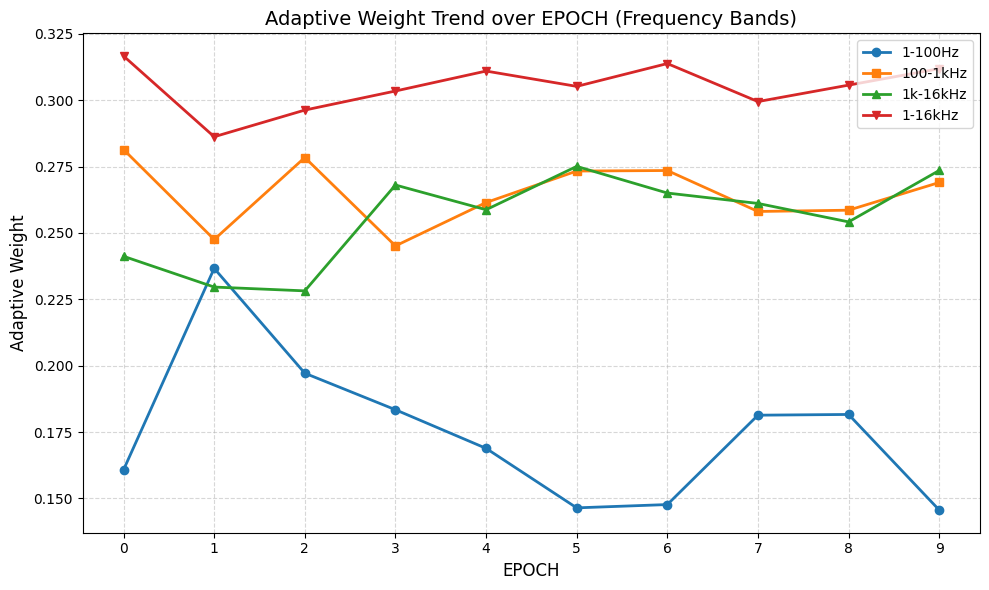

In [37]:
import matplotlib.pyplot as plt
import numpy as np

def plot_adaptive_weights_trend_mel_only(history_list):
    if not history_list:
        print("目前無訓練紀錄。")
        return

    # 1. 提取歷史數據
    epochs = [h['epoch'] for h in history_list]
    f1_accs = np.array([h.get('f1', 0) for h in history_list])
    f2_accs = np.array([h.get('f2', 0) for h in history_list])
    f3_accs = np.array([h.get('f3', 0) for h in history_list])
    f4_accs = np.array([h.get('f4', 0) for h in history_list])

    # 2. 計算正規化權重 (基於論文 Eq. 6)
    total_acc = f1_accs + f2_accs + f3_accs + f4_accs + 1e-9
    w1, w2, w3, w4 = f1_accs/total_acc, f2_accs/total_acc, f3_accs/total_acc, f4_accs/total_acc

    # 3. 繪製趨勢圖
    plt.figure(figsize=(10, 6))
    # 根據用戶要求修改標籤為具體頻段
    plt.plot(epochs, w1, marker='o', label='1-100Hz', linewidth=2)
    plt.plot(epochs, w2, marker='s', label='100-1kHz', linewidth=2)
    plt.plot(epochs, w3, marker='^', label='1k-16kHz', linewidth=2)
    plt.plot(epochs, w4, marker='v', label='1-16kHz', linewidth=2)

    plt.title('Adaptive Weight Trend over EPOCH (Frequency Bands)', fontsize=14)
    plt.xlabel('EPOCH', fontsize=12)
    plt.ylabel('Adaptive Weight', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.xticks(epochs)
    plt.tight_layout()
    plt.show()

# 執行繪圖函數
if 'history' in globals() and len(history) > 0:
    plot_adaptive_weights_trend_mel_only(history)
else:
    print("尚未找到訓練歷史紀錄 (history)。")

### Step 15：Adaptive Weight 隨 EPOCH 變化趨勢圖 (CQT 與各頻段對比)

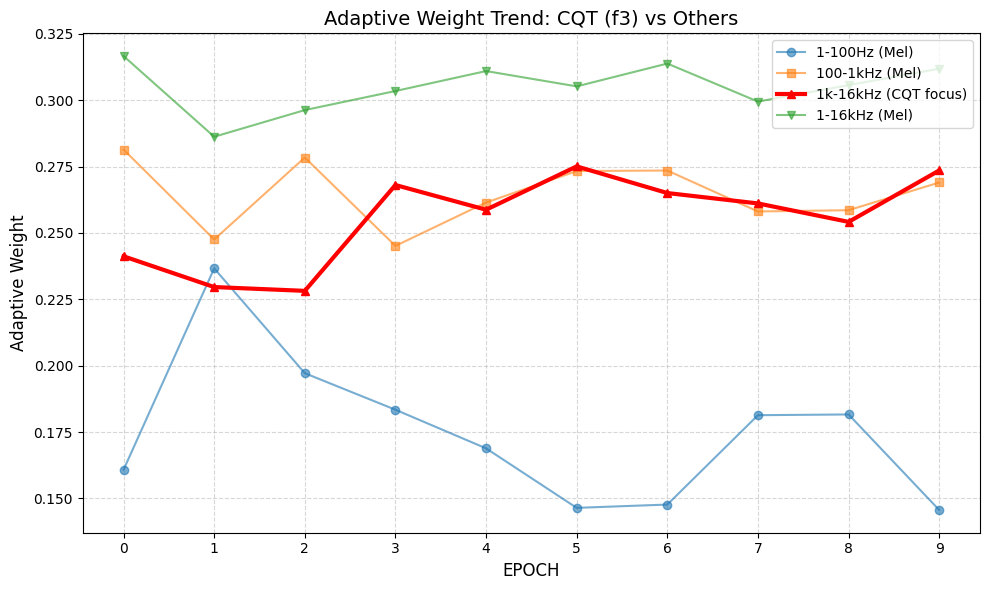

In [39]:
import matplotlib.pyplot as plt
import numpy as np

def plot_adaptive_weights_cqt_focus(history_list):
    if not history_list:
        print("目前無訓練紀錄。")
        return

    # 1. 提取歷史數據 (f1-f4)
    epochs = [h['epoch'] for h in history_list]
    f1_accs = np.array([h.get('f1', 0) for h in history_list])
    f2_accs = np.array([h.get('f2', 0) for h in history_list])
    f3_accs = np.array([h.get('f3', 0) for h in history_list])
    f4_accs = np.array([h.get('f4', 0) for h in history_list])

    # 2. 計算正規化權重 (基於論文 Eq. 6)
    total_acc = f1_accs + f2_accs + f3_accs + f4_accs + 1e-9
    w1, w2, w3, w4 = f1_accs/total_acc, f2_accs/total_acc, f3_accs/total_acc, f4_accs/total_acc

    # 3. 繪製趨勢圖
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, w1, marker='o', label='1-100Hz (Mel)', alpha=0.6)
    plt.plot(epochs, w2, marker='s', label='100-1kHz (Mel)', alpha=0.6)
    plt.plot(epochs, w3, marker='^', label='1k-16kHz (CQT focus)', linewidth=3, color='red')
    plt.plot(epochs, w4, marker='v', label='1-16kHz (Mel)', alpha=0.6)

    plt.title('Adaptive Weight Trend: CQT (f3) vs Others', fontsize=14)
    plt.xlabel('EPOCH', fontsize=12)
    plt.ylabel('Adaptive Weight', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.xticks(epochs)
    plt.tight_layout()
    plt.show()

# 執行繪圖
if 'history' in globals() and len(history) > 0:
    plot_adaptive_weights_cqt_focus(history)
else:
    print("尚未找到訓練歷史紀錄。")

### Step 16：消融實驗 C 數據彙整 (Mel 與 CQT 綜合分析)
此表彙整了各個頻段分支的類型、自適應權重 (AW) 以及各項性能指標。

In [40]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

def get_ablation_c_metrics(model, dl, device, history_list):
    model.eval()
    branches = {
        'f1 (1-100Hz)': ('Mel', 'f1'),
        'f2 (100-1kHz)': ('Mel', 'f2'),
        'f3 (1k-16kHz)': ('CQT', 'f3'),
        'f4 (1-16kHz)': ('Mel', 'f4'),
        'Mixed Branch': ('Fusion', 'mixed')
    }

    # 1. 獲取最後一個 Epoch 的權重
    last_h = history_list[-1]
    acc_list = np.array([last_h.get('f1', 0), last_h.get('f2', 0), last_h.get('f3', 0), last_h.get('f4', 0)])
    weights = acc_list / (acc_list.sum() + 1e-9)

    all_preds = {k: [] for k in branches.keys()}
    all_labels = []

    # 2. 評估指標
    with torch.no_grad():
        for x_dict, y in tqdm(dl, desc='Calculating Metrics for Ablation C'):
            x_dict = {k: v.to(device) for k, v in x_dict.items()}
            out = model(x_dict)
            for label, (feat_type, key) in branches.items():
                all_preds[label].extend(out[key].argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())

    results = []
    for i, (label, (feat_type, key)) in enumerate(branches.items()):
        preds = np.array(all_preds[label])
        labels = np.array(all_labels)

        acc = (preds == labels).mean()
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)

        # 分配權重 (Mixed Branch 不適用單一權重)
        aw = f"{weights[i]:.4f}" if i < 4 else "N/A"

        results.append({
            'Types of Features': f"{feat_type} ({label})",
            'Adaptive Weight (AW)': aw,
            'Accuracy (%)': f"{acc*100:.2f}%",
            'Precision (%)': f"{p*100:.2f}%",
            'Recall (%)': f"{r*100:.2f}%",
            'F1-score (%)': f"{f1*100:.2f}%"
        })

    return pd.DataFrame(results)

# 執行並顯示
if 'history' in globals() and len(history) > 0:
    ablation_c_table = get_ablation_c_metrics(model, dl_test, device, history)
    display(ablation_c_table)
else:
    print("請先確保已有訓練歷史紀錄 (history)。")

Calculating Metrics for Ablation C:   0%|          | 0/27 [00:00<?, ?it/s]

,Types of Features,Adaptive Weight (AW),Accuracy (%),Precision (%),Recall (%),F1-score (%)
0,Mel (f1 (1-100Hz)),0.1456,24.66%,29.35%,25.03%,10.37%
1,Mel (f2 (100-1kHz)),0.2690,45.55%,45.73%,45.14%,45.17%
2,CQT (f3 (1k-16kHz)),0.2735,46.31%,47.63%,46.11%,45.82%
3,Mel (f4 (1-16kHz)),0.3118,52.80%,52.47%,52.24%,52.26%
4,Fusion (Mixed Branch),N/A,57.99%,58.80%,57.26%,57.07%
